# thalamus: spindle3

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\utils'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
params = dp.loadDefaultParams(0)
params["dt"] = 0.0001
#params["Jet"] = 1.98
params 

{'dt': 0.0001,
 'duration': 10,
 'model': 'spindle3',
 'seed': 0,
 'tau_t': 0.044,
 'tau_r': 0.022,
 'f_t_max': 250,
 'f_r_max': 200,
 'f_t_th': 50,
 'f_r_th': 110,
 'gamma_t': 0.01,
 'gamma_r': 0.01,
 'At': 0.006875,
 'Ar': 0.006875,
 'tau_u_t': 0.22,
 'tau_u_r': 0.11,
 'RT_t': 100,
 'RT_r': 180,
 'RB_t': 250,
 'RB_r': 250,
 'VT_t': 26,
 'VT_r': 23,
 'VB_t': 15,
 'VB_r': 15,
 'gT_t': 6,
 'gT_r': 3,
 'gB_t': 0.9,
 'gB_r': 0.6,
 'Lt': 0.04,
 'Lr': 0.04,
 'Nt': 500.0,
 'Nr': 500.0,
 'Prr': 0.02,
 'Ptr': 0.01,
 'Prt': 0.04,
 'Jrr': -1.5,
 'Jtr': 3.42,
 'Jrt': -6.4,
 'tau_e': 0.02,
 'tau_i': 0.01,
 'tau_c': 0.5,
 'Ne': 8000.0,
 'Ni': 2000.0,
 'delta_c': 0.005,
 'delta_c2': 0.0054,
 'ge': 5,
 'gi': 2,
 'Rm': 70,
 'V_star': 30,
 'c_star': 10,
 'gc': 3,
 'Pee': 0.2,
 'Pe2e': 0.01,
 'Pee2': 0.01,
 'Pie': 0.2,
 'Pte': 0.02,
 'Pii': 0.2,
 'Pei': 0.2,
 'Pe2i': 0.01,
 'Pei2': 0.01,
 'Pti': 0.02,
 'Pet': 0.01,
 'Per': 0.01,
 'Jee0': 0.38,
 'Je2e0': 0.67,
 'Jee20': 0.3,
 'Jet': 1.98,
 'Je2t': 1.67,


In [3]:
# for test

#t, Q_t, Q_r, V_t, V_r, a_chunk, b_chunk, c_chunk, u_chunk, ar_chunk, br_chunk, cr_chunk, dr_chunk, ur_chunk = rm.runModels(manual_params=params)
t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, u_chunk, ur_chunk = rm.runModels(manual_params=params)


d:\mynew\demo_all\models\spindle_3\timeIntegration.py:342: RuntimeWarning: overflow encountered in exp
  return f_t_max / (1 + np.exp((u+f_t_th)/gamma_t))
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:344: RuntimeWarning: overflow encountered in exp
  return f_r_max / (1 + np.exp((u+f_r_th)/gamma_r))
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:342: RuntimeWarning: overflow encountered in exp
  return f_t_max / (1 + np.exp((u+f_t_th)/gamma_t))
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:344: RuntimeWarning: overflow encountered in exp
  return f_r_max / (1 + np.exp((u+f_r_th)/gamma_r))


In [4]:

#print(t)
#print(V_t[:100])
#print("a:", a_chunk[:100])
#print("b:", b_chunk[:100])
#print("c:", c_chunk[:100])
#print("u:", u_chunk[:100])
#print("Q_e:", Q_e[1000:2000])

In [5]:

import yasa
import xarray as xr
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * 10000
print(sf)
sp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")
#len(sp.summary()) # 9.7s, _events 9.5s
rate1 = len(sp1._events) / duration if sp1 else 0
print(rate1)

sp2 = yasa.spindles_detect(V_t , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TCR:",sp2.summary()) if sp2 else  print("NO spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate2 = len(sp2._events) / duration if sp2 else 0
print(rate2)

sp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")
#len(sp.summary()) # 9.7s, _events 9.5s
rate3 = len(sp3._events) / duration if sp3 else 0
print(rate3)

d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.6.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
23-Jan-26 14:04:56 | WARNING | No spindle were found in channel CHAN000.
23-Jan-26 14:04:56 | WARNING | No spindles were found in data. Returning None.


10000.0
NO spindle in EXC
0


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
23-Jan-26 14:04:56 | ERROR | Wrong data amplitude for CHAN000 (trimmed STD = 0.006). Unit of data MUST be uV! Channel will be skipped.
23-Jan-26 14:04:56 | WARNING | All channels have bad amplitude. Returning None.


TCR:     Start    Peak     End  Duration  Amplitude       RMS  AbsPower  RelPower  \
0  0.3153  0.4283  1.0475    0.7322   1.411598  0.302946 -1.109038  0.316738   
1  2.0276  2.3107  3.3400    1.3124   1.521445  0.280578 -1.090131  0.378551   
2  6.4773  7.8890  8.0104    1.5331   1.531267  0.279747 -1.214709  0.387079   
3  8.5443  8.6239  9.1118    0.5675   1.663047  0.347951 -1.019282  0.324765   

   Frequency  Oscillations  Symmetry  Channel  IdxChannel  
0  13.149983          10.0  0.154308  CHAN000           0  
1  13.797816          15.0  0.215695  CHAN000           0  
2  13.699533          20.0  0.920754  CHAN000           0  
3  12.982169           7.0  0.140240  CHAN000           0  
0.4
NO spindle in TRN
0


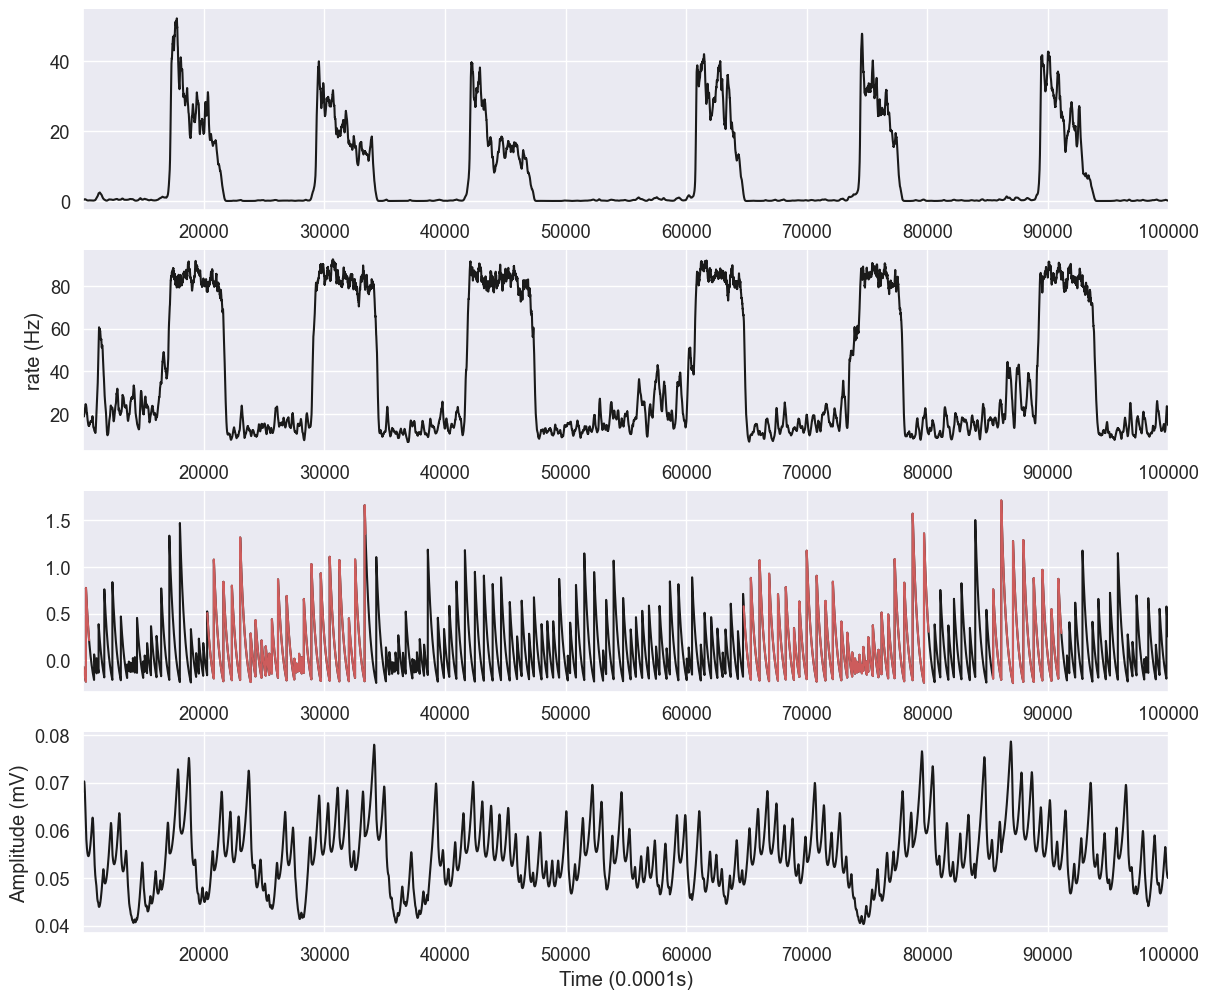

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(4, 1, figsize=(14, 12))

#plt.title('N2 sleep EEG data (2 spindles)')

plt.setp(ax, xlim=(t[10000:].min(), t[10000:].max()))
#plt.xlim([t.min(), t.max()])
#plt.xlim([t[10000:].min()/10000, t[10000:].max()/10000])

plt.subplot(4,1,1)
#plt.plot(t, Q_e*1000, lw=1.5, color='k')
plt.plot(t[10000:], Q_e[10000:]*1000, lw=1.5, color='k')
if sp1:
    mask1 = sp1.get_mask()
    spindles_highlight_e = Q_e * mask1
    spindles_highlight_e[spindles_highlight_e == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight_e[10000:]*1000, 'indianred')

plt.subplot(4,1,2)
plt.plot(t[10000:], Q_i[10000:]*1000, lw=1.5, color='k')
#plt.plot(t, Q_i*1000, lw=1.5, color='k')
plt.ylabel('rate (Hz)')


plt.subplot(4,1,3)
#plt.plot(t, V_t, lw=1.5, color='k')
plt.plot(t[10000:], V_t[10000:], lw=1.5, color='k')
mask2 = sp2.get_mask()
spindles_highlight = V_t * mask2
spindles_highlight[spindles_highlight == 0] = np.nan
plt.plot(t[10000:], spindles_highlight[10000:], 'indianred')


plt.subplot(4,1,4)
#plt.plot(t, V_r, lw=1.5, color='k')
plt.plot(t[10000:], V_r[10000:], lw=1.5, color='k')
plt.xlabel('Time (0.0001s)')
plt.ylabel('Amplitude (mV)')


sns.despine()

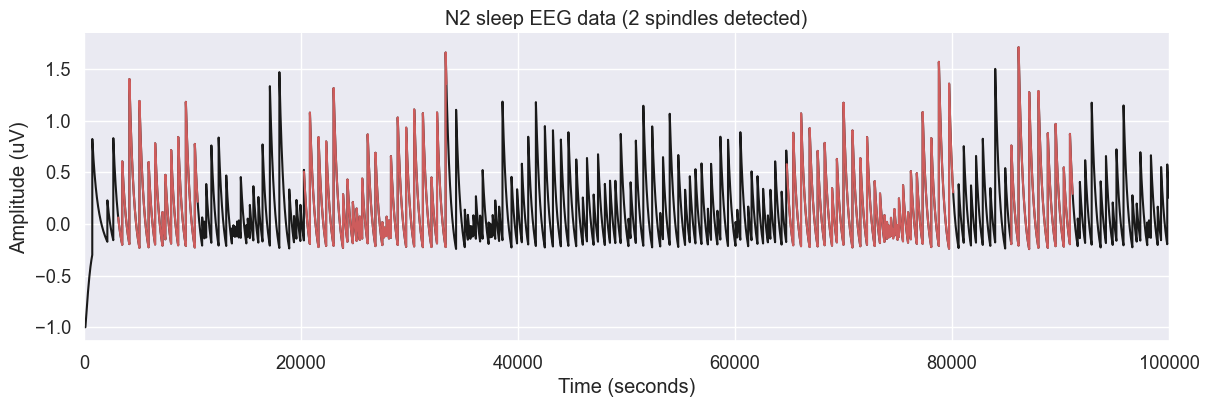

In [7]:
# Let's get a bool vector indicating for each sample
mask = sp2.get_mask()

# Now let's plot
spindles_highlight = V_t * mask
spindles_highlight[spindles_highlight == 0] = np.nan

plt.figure(figsize=(14, 4))
plt.plot(t, V_t, 'k')
plt.plot(t, spindles_highlight, 'indianred')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([0, t[-1]])
plt.title('N2 sleep EEG data (2 spindles detected)')
sns.despine()
# plt.savefig('detection.png', dpi=300, bbox_inches='tight')

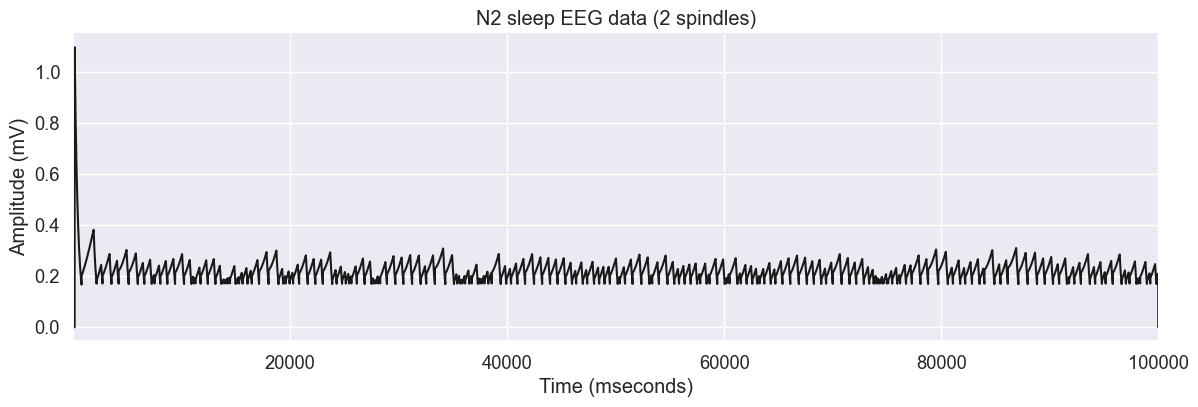

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t, Q_t, lw=1.5, color='k')
#plt.plot(t, V_t, lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#plt.xlim([t.min(), t.max()])
plt.xlim([t.min(), t.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [9]:
print(V_e[:100])
#print("ar:", ar_chunk[:100])
#print("br:", br_chunk[:100])
#print("cr:", cr_chunk[:100])
#print("dr:", dr_chunk[:100])
#print("ur:", ur_chunk[:100])
print("Q_r:", Q_r[:100])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]
Q_r: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


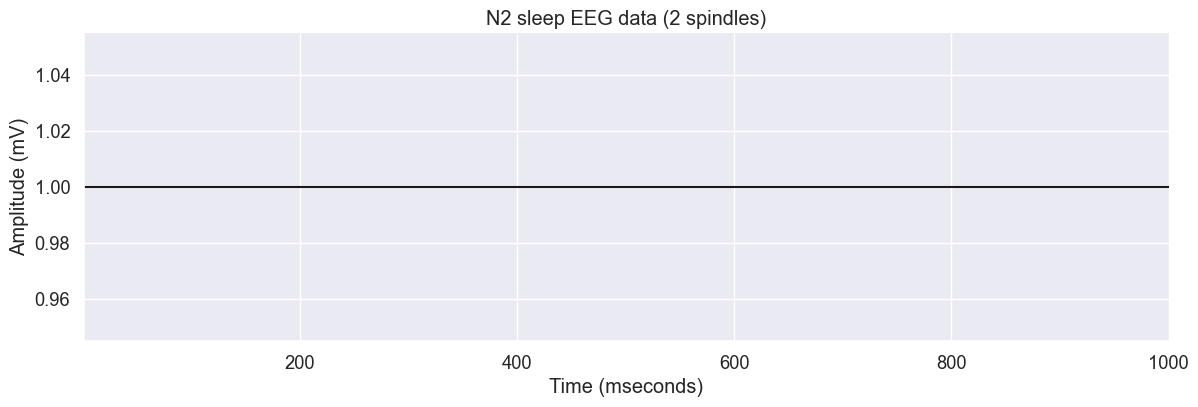

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t[:1000], V_e[:1000], lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
plt.xlim([t[:1000].min(), t[:1000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [11]:

parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'model': ['spindle1']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [12]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'thalamus_demo.hdf') 

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

number of cores: 28


In [13]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

AttributeError: g_h is not part of your trajectory or it's tree. 

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:
traj.f_get_parameters()


In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.g_LK'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.g_h'].f_get_range()
print(b)



In [ ]:
traj.results.thalamus_results[0].V_t[0]
# traj.results.thalamus_results[0].V_t[0][:-1] # pay attention to the length(why longer than t?)
# traj.results.thalamus_results[0].f_to_dict()

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
from tqdm import *
num_cores = multiprocessing.cpu_count()

import yasa
duration = params["duration"] / 1000
sf = float(1.0 / (t[1] - t[0])) * 1000
sp = yasa.spindles_detect(V_t[0], sf)
#len(sp.summary()) # 9.7s, _events 9.5s

def cal_spindles(i):
    sp = yasa.spindles_detect(traj.results.thalamus_results[i].V_t[0], sf)
    rate = len(sp._events) / duration if sp else 0
    return rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_spindles)(i) for i in tqdm(range(len(dfResults))))
print(plot_results)


In [ ]:
import matplotlib.pyplot as plt

g_LK = np.unique(dfResults['g_LK'])
g_h = np.unique(dfResults['g_h'])
plot_results_matrix = np.reshape(plot_results, (len(g_LK), len(g_h)))

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[g_LK[0], g_LK[-1], g_h[0], g_h[-1]])

plt.xlabel("g_LK", fontsize=30)
plt.ylabel("g_h", fontsize=30)
plt.clim(0, 0.3)
cbar = plt.colorbar(label="spindles", extend='max')
plt.show()

In [ ]:
# spindle detection
import yasa
import logging
def scale_to_voltage(dataarray, feature_range=(-80, -20)):
    data_scale = (feature_range[1]- feature_range[0]) / (
        dataarray.max(dim="time") - dataarray.min(dim="time")
    )
    data_min = feature_range[0] - dataarray.min(dim="time") * data_scale
    return data_scale * dataarray + data_min
def spindles_detect_thalamus(tcr_ts, trn_ts=None, trn_median_thresh=5.0, **kwargs):
    assert tcr_ts.ndim == 1, "Only works on 1D timeseries"
    if tcr_ts.max() < 10.0 or tcr_ts.std() < 5.0:
        logging.warning("No spindles found: STD too low")
        return None
    if trn_ts is not None and np.nanmedian(trn_ts) < trn_median_thresh:
        logging.warning("No spindles found: TRN is not oscillating")
        return None
    sf = float(1.0 / (tcr_ts.time[1] - tcr_ts.time[0]))
    return yasa.spindles_detect(
        scale_to_voltage(tcr_ts).values, sf=sf, **kwargs
    )


In [ ]:
import yasa
import xarray as xr
# print(V_t)
print("V_t.shape:", V_t.shape)
data = np.diff(V_t[0]) * 1000  # pay attention to the unit(mV or uV)
# print(data)
print(data.shape)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

t1 = t[2000000:3000000] / 1000
print(t1.shape)
data1 = data[2000000:3000000]
print(data1.shape)


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t1, data1, lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([t1.min(), t1.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

coords = t1
# 7000
tcr_ts = xr.DataArray(data1, coords=[coords], dims=['time'])

sf = 100000 # !!!  1000,000 data for 10 seconds
sp = yasa.spindles_detect(tcr_ts, sf, duration=(0.3, 2))
sp.summary()



In [ ]:

import xarray as xr
data = traj.results.thalamus_results[0].V_t[0][:-1] *1000 # pay attention to the unit(mV or uV)
coords = traj.results.thalamus_results[0].t
# 7000
tcr_ts = xr.DataArray(data, coords=[coords], dims=['time'])

sf = 200
sp = yasa.spindles_detect(tcr_ts, sf)
sp.summary()
